<a href="https://colab.research.google.com/github/Fatcatinthesnow/soccer-transfer-value-predictor/blob/main/Transfermarket_Value_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Soccer Transfer Value Predictor

Predicts football players' current market value (€) from performance and profile stats — age, goals, assists, minutes played, appearances, and position.

Data: Football Players Transfer Fee Prediction Dataset (Kaggle), pulled via kagglehub.

Approach: Clean and explore the data, engineer features (one-hot encoded position), then train and compare four regression models — KNN, Random Forest, Gradient Boosting, and SVR — evaluating each on MAE and R².

Result: Gradient Boosting performed best (R² = 0.42, MAE ≈ €3.1M), a meaningful improvement over the KNN baseline (R² = 0.16).

##Importing Data Set

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khanghunhnguyntrng/football-players-transfer-fee-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 549k/549k [00:00<00:00, 836kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/khanghunhnguyntrng/football-players-transfer-fee-prediction-dataset/versions/2


In [ ]:
import os
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

/root/.cache/kagglehub/datasets/khanghunhnguyntrng/football-players-transfer-fee-prediction-dataset/versions/2/final_data.csv


## Importing Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn import svm
import numpy as np
players = pd.read_csv("/root/.cache/kagglehub/datasets/khanghunhnguyntrng/football-players-transfer-fee-prediction-dataset/versions/2/final_data.csv")

## Summary Statistics and Data Visualization


In [ ]:
players.head()
players.columns

Index(['player', 'team', 'name', 'position', 'height', 'age', 'appearance',
       'goals', 'assists', 'yellow cards', 'second yellow cards', 'red cards',
       'goals conceded', 'clean sheets', 'minutes played', 'days_injured',
       'games_injured', 'award', 'current_value', 'highest_value',
       'position_encoded', 'winger'],
      dtype='object')

In [ ]:
print(players["position"].unique())

['Goalkeeper' 'Defender Centre-Back' 'Defender Left-Back'
 'Defender Right-Back' 'midfield-DefensiveMidfield'
 'midfield-CentralMidfield' 'midfield-AttackingMidfield'
 'Attack-LeftWinger' 'Attack-RightWinger' 'Attack Centre-Forward'
 'midfield-RightMidfield' 'midfield-LeftMidfield' 'Attack-SecondStriker'
 'midfield' 'Attack' 'Defender']


<Figure size 640x480 with 0 Axes>

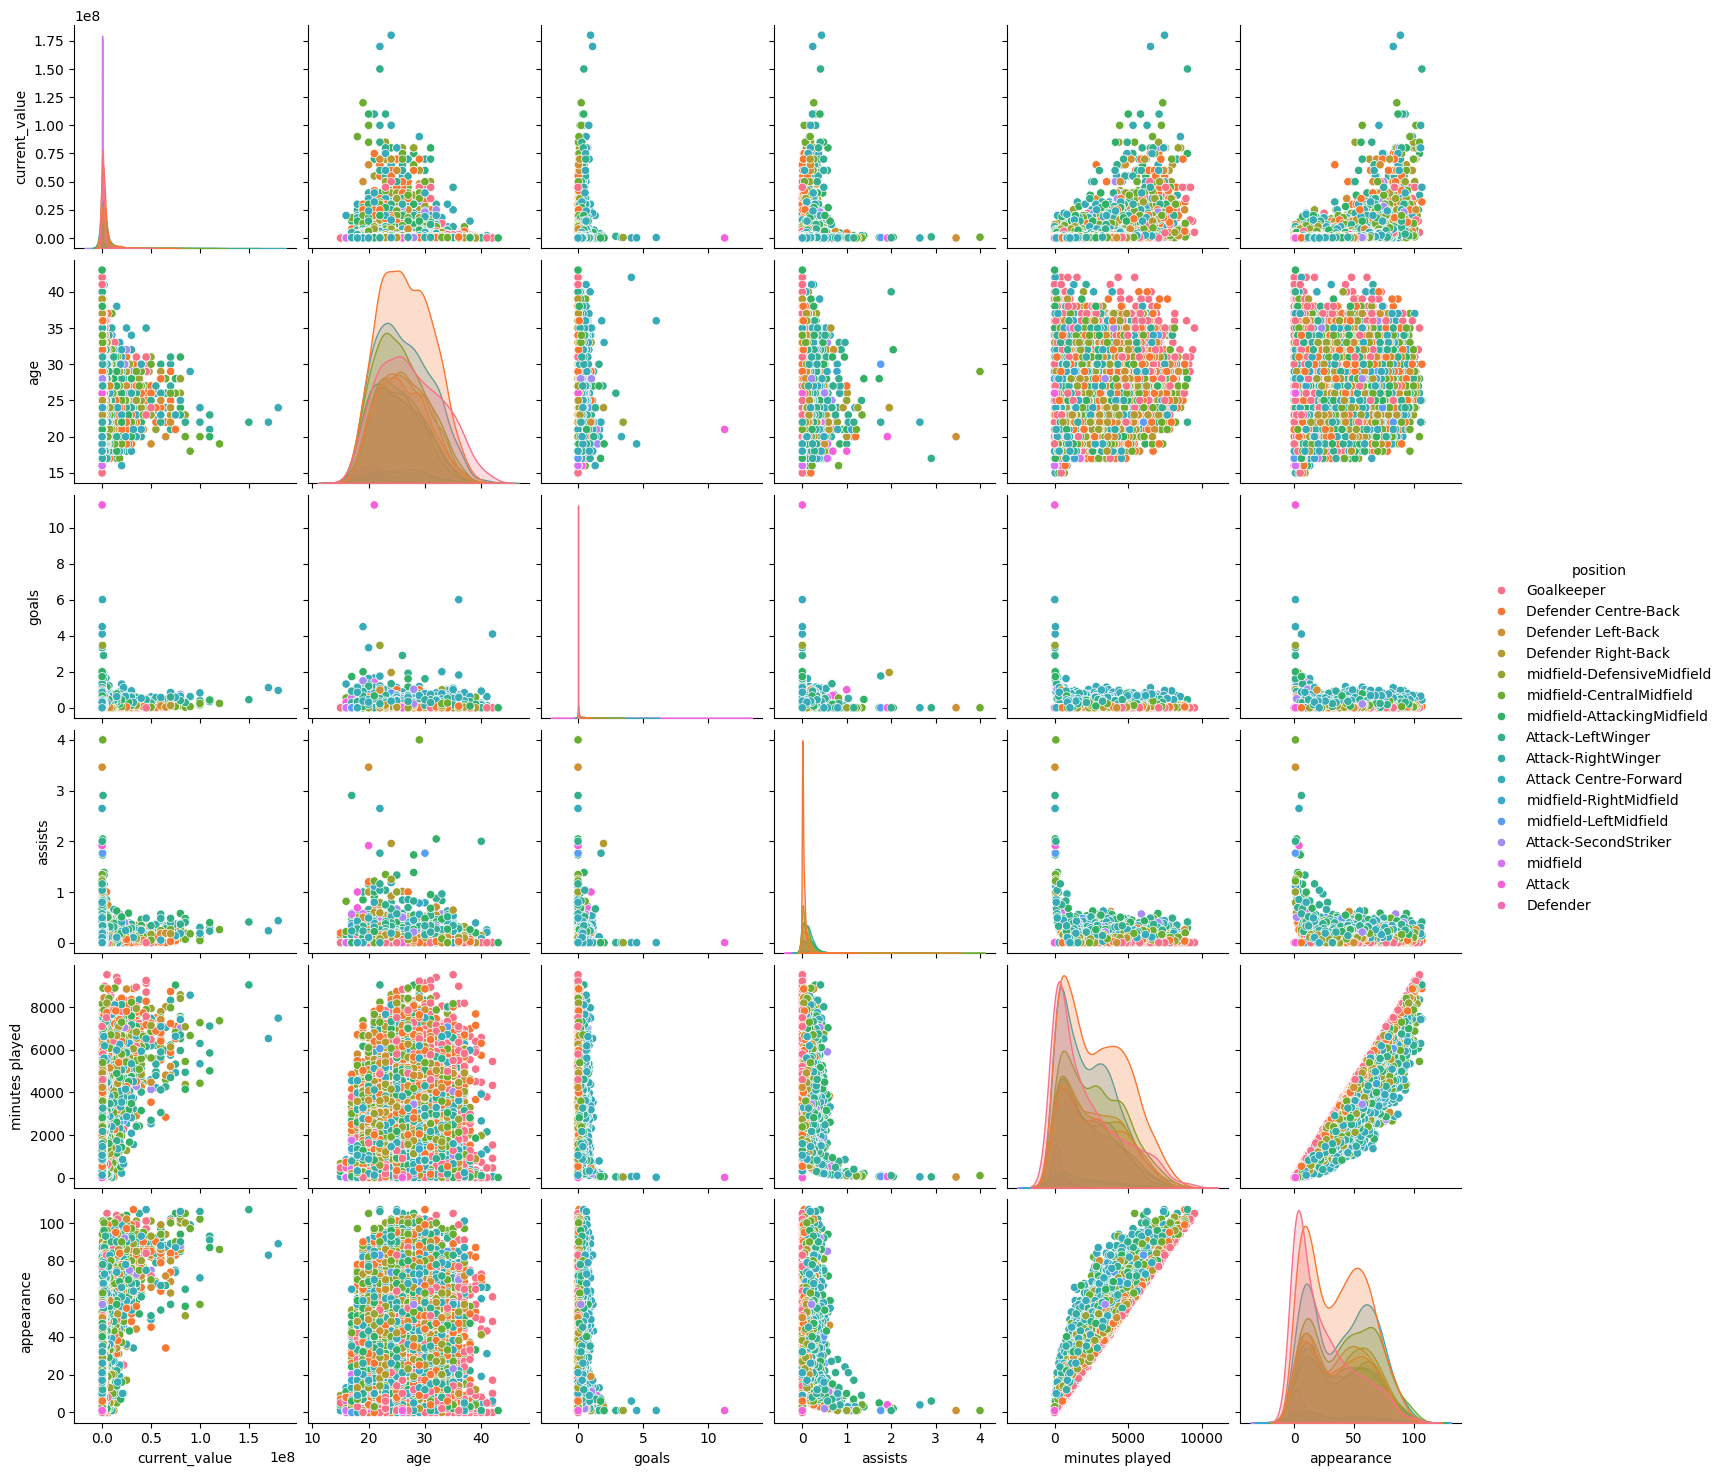

In [ ]:
plt.figure()
sns.pairplot(players, vars=["current_value", "age", "goals", "assists", "minutes played", "appearance"], hue = "position")
plt.show()

From the graphs there appears to be a slight correlation current value of players and every other factor. Age and position are a little questionable, but we'll still include them to take every factor into account. Let's convert position into dummies since all models used require numerical inputs.

In [ ]:
players_encoded = pd.get_dummies(players, columns=["position"])

## Training Testing split


In [ ]:
from sklearn.model_selection import train_test_split
position_cols = [c for c in players_encoded.columns if c.startswith("position_")]
features = ["age", "goals", "assists", "minutes played", "appearance"] + position_cols
x = players_encoded[features].values
y = players_encoded["current_value"].values

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## K Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

regressor = KNeighborsRegressor(n_neighbors=5)
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 3596377.0339377034
R2: 0.1596642089470448


On average when k=5, the model predictions are off by €3.6 million from the actual data. But a R2 of .160 means that the model is barely better than a guess. This could be because the higher market value outliers really skews with how nearest neighbor works. Let's try to increase the value of k:

In [ ]:
regressor = KNeighborsRegressor(n_neighbors=25)
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 3513540.306834031
R2: 0.23389903276842683


Much Better! There's a slight improvement in the absolute error of the mean, but a R2 of .234 is much better than .160; a 46.25% increase!

## Decision Trees

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("RF MAE:", mean_absolute_error(y_test, rf_preds))
print("RF R2:", r2_score(y_test, rf_preds))

RF MAE: 3319060.3207292208
RF R2: 0.3865472406852638


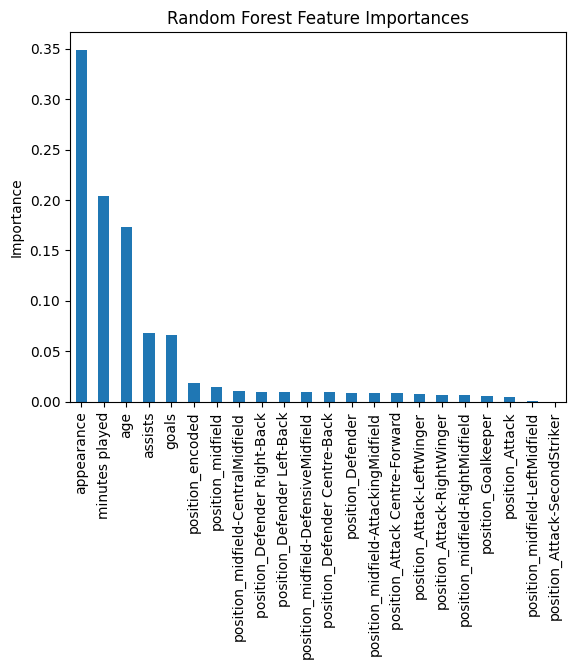

In [ ]:
rf_importances = pd.Series(rf.feature_importances_, index=features)
rf_importances.sort_values(ascending=False).plot(kind="bar")
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.show()

The R2 value is better than the random neighbors by alot, but there's still a lot of room for improvement. Lets try to log-transform the tree to combat the skewness:


In [ ]:
y_log = np.log1p(y)
X_train, X_test, y_train_log, y_test_log = train_test_split(x, y_log, test_size=0.2, random_state=42)
rf.fit(X_train, y_train_log)
preds_log = rf.predict(X_test)
preds_actual = np.expm1(preds_log)  # convert back to euros
y_test_actual = np.expm1(y_test_log)
print("MAE:", mean_absolute_error(y_test_actual, preds_actual))
print("R2:", r2_score(y_test_actual, preds_actual))

MAE: 2735343.406516826
R2: 0.3065138889003356


MAE improved (€3.32M → €2.74M) but R² actually got worse (0.39 → 0.31).

## Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)

print("GB MAE:", mean_absolute_error(y_test, gb_preds))
print("GB R2:", r2_score(y_test, gb_preds))

GB MAE: 3113761.467107002
GB R2: 0.4161314171591759


MAE worsened (€2.74M → 3.11M) but R2 improved (0.31 → 0.42)

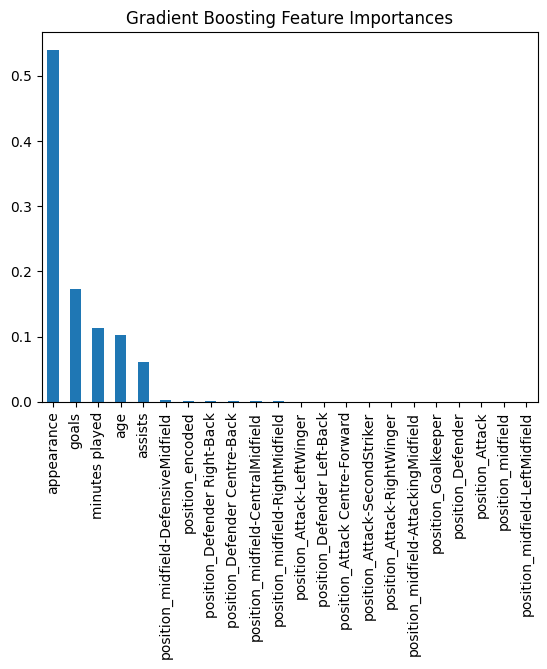

In [ ]:
importances = pd.Series(gb.feature_importances_, index=features)
importances.sort_values(ascending=False).plot(kind="bar")
plt.title("Gradient Boosting Feature Importances")
plt.show()

Interestly enough, Gradient Boosting seems to disagree with Random Forest model on the importance of goals by a wide margin. It also places lower importance on the position of players than the trees: it's actually almost an negligible amount.

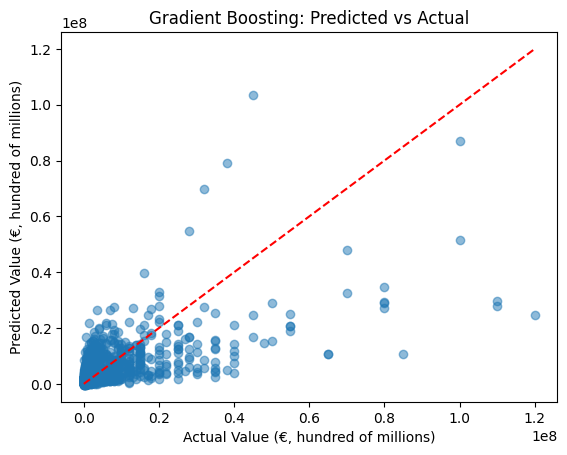

In [ ]:
plt.scatter(y_test, gb_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Value (€, hundred of millions)")
plt.ylabel("Predicted Value (€, hundred of millions)")
plt.title("Gradient Boosting: Predicted vs Actual")
plt.show()

Model seems to be really efficent for lower-valued players, but there's a large discrepancy amongst higher-valued players

## Support Vector Machine

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr = SVR()
svr.fit(X_train_scaled, y_train)
svr_preds = svr.predict(X_test_scaled)

print("SVR MAE:", mean_absolute_error(y_test, svr_preds))
print("SVR R2:", r2_score(y_test, svr_preds))

SVR MAE: 3318387.694391369
SVR R2: -0.08826561375439868


To put is bluntly, terrible results. R2 is negative, meaning SVR in this case performed worse than just actually guessing.

## Demo

feel free to try it yourself and play around with it!

In [ ]:
def predict_player_value(age, goals, assists, minutes_played, appearance, position):
    input_data = pd.DataFrame({
        "age": [age],
        "goals": [goals],
        "assists": [assists],
        "minutes played": [minutes_played],
        "appearance": [appearance],
        "position": [position]
    })

    input_encoded = pd.get_dummies(input_data, columns=["position"])


    for col in position_cols:
        if col not in input_encoded.columns:
            input_encoded[col] = 0

    input_final = input_encoded[features]

    prediction = gb.predict(input_final)[0]
    return prediction

In [ ]:
age = float(input("Age: "))
goals = int(input("Goals: "))
assists = int(input("Assists: "))
minutes_played = int(input("Minutes played: "))
appearance = int(input("Appearances: "))
valid_positions = [c.replace('position_', '') for c in position_cols]
while True:
    position = input(f"Position (one of {valid_positions}): ")
    if position in valid_positions:
        break
    else:
        print("check spelling")


predicted_value = predict_player_value(age, goals, assists, minutes_played, appearance, position)
print(f"Predicted value: €{predicted_value:,.0f}")

Age: 17
Goals: 29
Assists: 1
Minutes played: 1830
Appearances: 9
Position (one of ['encoded', 'Attack', 'Attack Centre-Forward', 'Attack-LeftWinger', 'Attack-RightWinger', 'Attack-SecondStriker', 'Defender', 'Defender Centre-Back', 'Defender Left-Back', 'Defender Right-Back', 'Goalkeeper', 'midfield', 'midfield-AttackingMidfield', 'midfield-CentralMidfield', 'midfield-DefensiveMidfield', 'midfield-LeftMidfield', 'midfield-RightMidfield']): idk
check spelling
Position (one of ['encoded', 'Attack', 'Attack Centre-Forward', 'Attack-LeftWinger', 'Attack-RightWinger', 'Attack-SecondStriker', 'Defender', 'Defender Centre-Back', 'Defender Left-Back', 'Defender Right-Back', 'Goalkeeper', 'midfield', 'midfield-AttackingMidfield', 'midfield-CentralMidfield', 'midfield-DefensiveMidfield', 'midfield-LeftMidfield', 'midfield-RightMidfield']): attack
check spelling
Position (one of ['encoded', 'Attack', 'Attack Centre-Forward', 'Attack-LeftWinger', 'Attack-RightWinger', 'Attack-SecondStriker', 'Defe

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(
